# 01 · Data and surprisal baseline

In [1]:
import sys, json, re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src").is_dir() and (p / "results").is_dir())
sys.path.insert(0, str(ROOT / "src"))
from utils import *

P = paths(ROOT)
FIG = P["figures"]
B, SEED = bootstrap_settings(ROOT)
set_style()
pd.set_option("display.precision", 3)

# Corpus summary

In [2]:
pred = {c: pd.read_csv(P["baseline"] / f"{c}_predictions.csv") for c in CORPORA}
comp = {c: pd.read_csv(P["baseline"] / f"{c}_model_comparison.csv") for c in CORPORA}
pd.DataFrame([{"Corpus": CORPUS_LABELS[c], "Texts": d.text_id.nunique(), "Words with RT": len(d),
               "Mean RT (ms)": d.primary_RT.mean(), "Median RT (ms)": d.primary_RT.median(),
               "Mean surprisal (bits)": d.surprisal.mean()} for c, d in pred.items()]).round(1)

,Corpus,Texts,Words with RT,Mean RT (ms),Median RT (ms),Mean surprisal (bits)
0,Provo · FFD,55,2743,207.7,207.2,6.2
1,Natural Stories · SPR,10,10256,338.5,330.1,5.4


# Reading times and surprisal

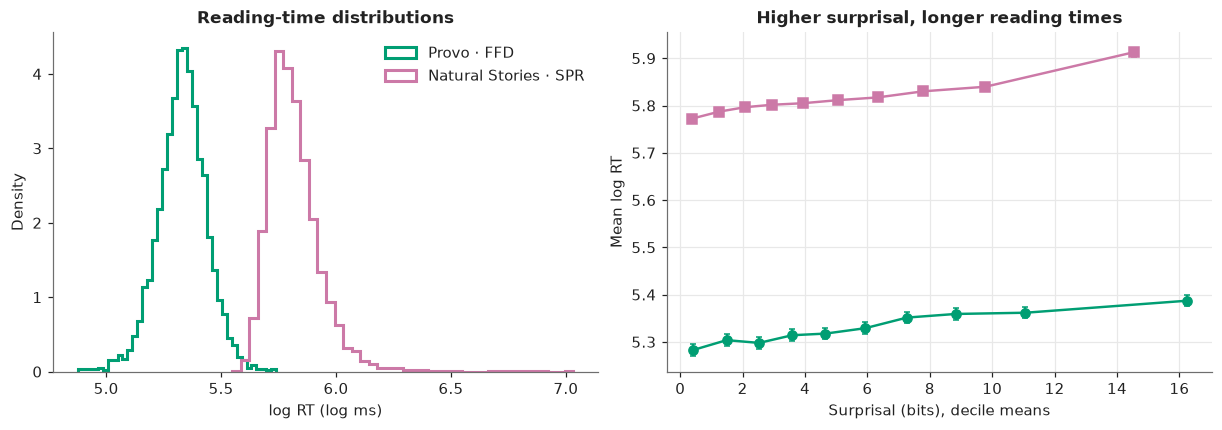

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), layout="constrained")
for c, d in pred.items():
    axes[0].hist(d.log_primary_RT, bins=40, histtype="step", lw=2, color=CORPUS_COLORS[c],
                 density=True, label=CORPUS_LABELS[c])
    bins = pd.qcut(d.surprisal, 10, duplicates="drop")
    g = d.groupby(bins, observed=True).agg(s=("surprisal", "mean"), y=("log_primary_RT", "mean"),
                                           se=("log_primary_RT", lambda v: v.std() / np.sqrt(len(v))))
    axes[1].errorbar(g.s, g.y, yerr=1.96 * g.se, color=CORPUS_COLORS[c], marker=CORPUS_MARKERS[c],
                     ms=6, lw=1.6, capsize=2, label=CORPUS_LABELS[c])
axes[0].set(xlabel="log RT (log ms)", ylabel="Density", title="Reading-time distributions")
axes[1].set(xlabel="Surprisal (bits), decile means", ylabel="Mean log RT", title="Higher surprisal, longer reading times")
axes[0].legend(); axes[1].grid(color=GRID)
save_figure(fig, FIG, "01_rt_and_surprisal"); plt.show()

# How much does surprisal add above lexical controls?

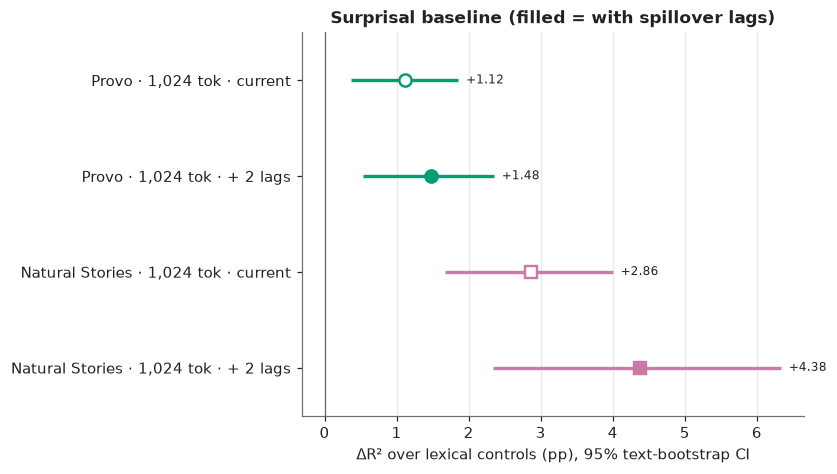

,label,est,lo,hi
0,"Provo · 1,024 tok · current",1.12,0.37,1.86
1,"Provo · 1,024 tok · + 2 lags",1.48,0.54,2.35
2,"Natural Stories · 1,024 tok · current",2.86,1.67,4.00
3,"Natural Stories · 1,024 tok · + 2 lags",4.38,2.34,6.34


In [7]:
names = {"long_current": "1,024 tok · current", "long_spillover": "1,024 tok · + 2 lags",
        # "matched_current": "128 tok · current", "matched_spillover": "128 tok · + 2 lags"
         }
rows = []
for c in CORPORA:
    t = comp[c].set_index("model")
    for m, lab in names.items():
        r = t.loc[m]
        rows.append(dict(label=f"{CORPUS_LABELS[c].split(' ·')[0]} · {lab}", corpus=c,
                         rep="sae" if "spillover" in m else "dense",
                         est=100 * r.delta_r2_vs_controls, lo=100 * r.delta_r2_ci_low, hi=100 * r.delta_r2_ci_high))
fig, ax = plt.subplots(figsize=(7.5, 4.2), layout="constrained")
forest(ax, rows, xlabel="ΔR² over lexical controls (pp), 95% text-bootstrap CI")
ax.set_title("Surprisal baseline (filled = with spillover lags)")
save_figure(fig, FIG, "01_surprisal_gain"); plt.show()
pd.DataFrame(rows)[["label", "est", "lo", "hi"]].round(2)